# Предсказание стоимости жилья

В проекте небходимо обучить модель линейной регрессии на данных о жилье в Калифорнии в 1990 году используя интрументы библиотеки MLlib Spark. На основе данных нужно предсказать медианную стоимость дома в жилом массиве, используя модель линейной регрессии. Для оценки качества модели используются метрики RMSE, MAE и R2.

## Подготовка данных

Подключим необходимые модули

### Установка библиотек

Для стабильной работы необходимо установить библиотеки определенных версий

In [1]:
!pip install -q pandas==1.2.4
!pip install -q numpy==1.21.1
!pip install -q scipy==1.9.1
!pip install -q pyspark==3.0.2
!pip install -q handyspark

In [2]:
from handyspark import *

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import *
import pyspark.sql.functions as F

In [5]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

In [6]:
pyspark_version = pyspark.__version__
if int(pyspark_version[:1]) >= 3:
    from pyspark.ml.feature import OneHotEncoder    
elif int(pyspark_version[:1]) == 2:
    from pyspark.ml.feature import OneHotEncodeEstimator

### Загрузка данных и ознакомление с ними

In [7]:
RANDOM_SEED = 2025

spark = SparkSession.builder \
                    .master("local") \
                    .appName("Household price project") \
                    .getOrCreate()

df = spark.read.option('header', 'true').csv('/datasets/housing.csv', inferSchema = True, header=True) 

In [8]:
df.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR BAY|
|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|
|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|
|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|       NEAR BAY|
|  -122.25|   37.85|              

Выведем схему с типами данных признаков:

In [9]:
df.printSchema()

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- ocean_proximity: string (nullable = true)



Сохраним наименования столбцов в отдельных переменных

In [10]:
col_names = df.columns

In [11]:
target = 'median_house_value'

In [12]:
cat_feat = ['ocean_proximity']
num_feat = col_names.copy()
num_feat.remove(cat_feat[0])
num_feat.remove(target)

### Поиск пропусков в данных

In [13]:
def check_col(column):
    return F.isnan(col=column) | F.isnull(col=column)

In [14]:
def na_search(data):
    columns = data.columns

    for column in columns:
        print(column, data.filter(check_col(column)).count())

In [15]:
df.summary().toPandas()

,summary,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,count,20640,20640,20640,20640,20433,20640,20640,20640,20640,20640
1,mean,-119.56970445736148,35.6318614341087,28.639486434108527,2635.7630813953488,537.8705525375618,1425.4767441860465,499.5396802325581,3.8706710029070246,206855.81690891474,None
2,stddev,2.003531723502584,2.135952397457101,12.58555761211163,2181.6152515827944,421.38507007403115,1132.46212176534,382.3297528316098,1.899821717945263,115395.61587441359,None
3,min,-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0,<1H OCEAN
4,25%,-121.8,33.93,18.0,1447.0,296.0,787.0,280.0,2.5625,119600.0,None
5,50%,-118.49,34.26,29.0,2127.0,435.0,1166.0,409.0,3.5347,179700.0,None
6,75%,-118.01,37.71,37.0,3146.0,647.0,1724.0,605.0,4.7426,264700.0,None
7,max,-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0,NEAR OCEAN


In [16]:
na_search(df)

longitude 0
latitude 0
housing_median_age 0
total_rooms 0
total_bedrooms 207
population 0
households 0
median_income 0
median_house_value 0
ocean_proximity 0


Обнаружено 207 пропусков, заменим их на средние значения:

In [17]:
mean_data = df.groupBy('ocean_proximity').agg(F.mean('total_bedrooms').alias('avg_total_bedrooms'))
mean_data.toPandas()

,ocean_proximity,avg_total_bedrooms
0,ISLAND,420.400000
1,NEAR OCEAN,538.615677
2,NEAR BAY,514.182819
3,<1H OCEAN,546.539185
4,INLAND,533.881619


In [18]:
#соединяем данные
mean_df = df.join(mean_data, on='ocean_proximity', how='left')

#если есть пустое значение, заменяем из столбца со средним
mean_df = mean_df.withColumn('total_bedrooms', F.coalesce(F.col('total_bedrooms'), F.col('avg_total_bedrooms')))

df = mean_df.drop('avg_total_bedrooms')

Проверим результат:

In [19]:
df.show(5)

+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|       NEAR BAY|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|
|       NEAR BAY|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|
|       NEAR BAY|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|
|       NEAR BAY|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|
|       NEAR BAY|  -122.25|   37.8

In [20]:
na_search(df)

ocean_proximity 0


longitude 0


latitude 0


housing_median_age 0


total_rooms 0


total_bedrooms 0


population 0


households 0


median_income 0


median_house_value 0


### Исследовательский анализ данных

Рассмотрим распределение признаков

In [21]:
hdf = df.toHandy()

In [22]:
def graph_stat_handy(data, rows, col):
    
    fig, ax = plt.subplots(rows, col, figsize=(16, 20))
    i = 0
    j = 0

    for column in data.columns:   

        data.cols[column].hist(bins=15, ax=ax[i, j])

        j += 1
        if j == col:
            j = 0
            i += 1

    plt.show()

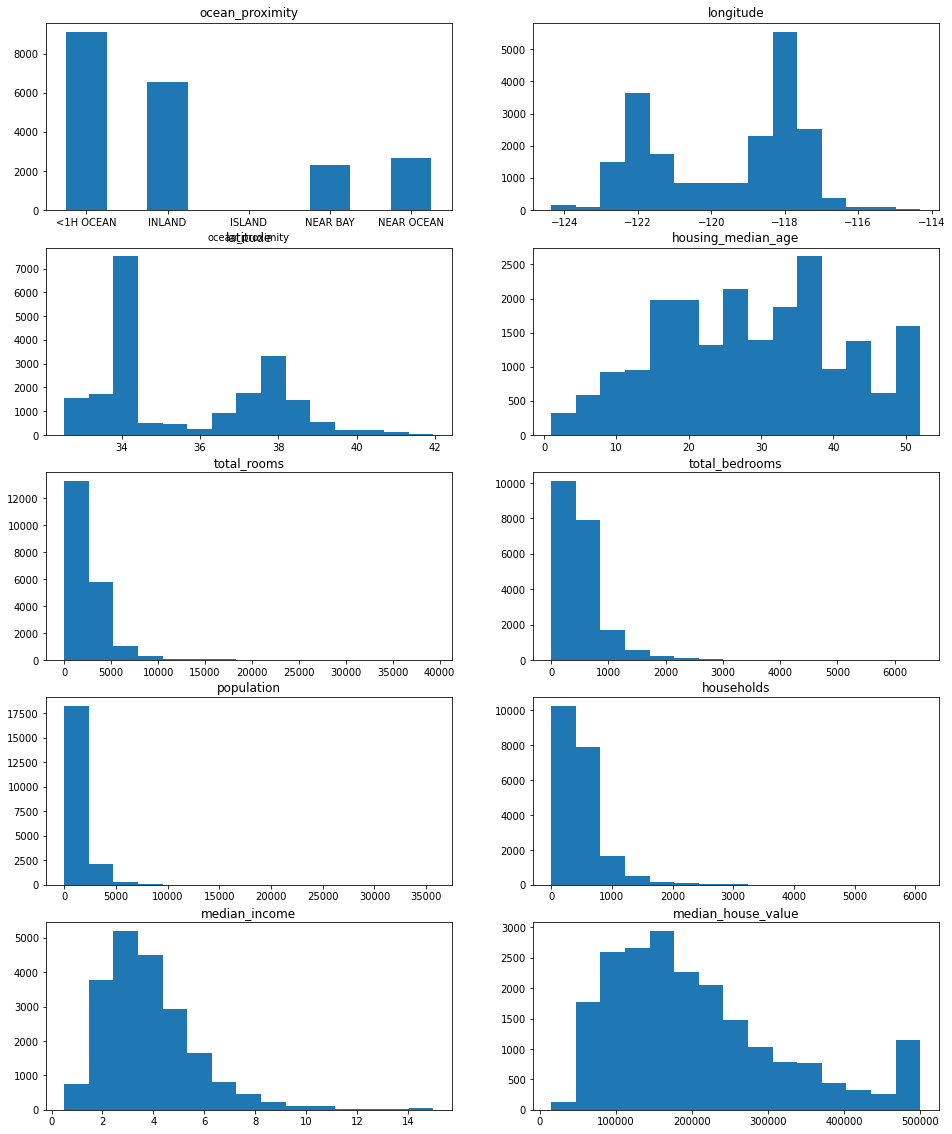

In [23]:
graph_stat_handy(hdf, 5, 2)

Большинство признаков, характеризующих жилые массивы, распределены схожим образом между собой и объяснимы с логической точки зрения - большинство домовладений в среднем не выделяются большой плошадью, числом комнат и т.д. Среди признаков выделяется только population - большая часть гистограмы пуста, что говорит о резко выделяющихся значениях, т.е. выбросах.

In [24]:
df.where(df.population > 10000).count()

23

Таких значений имеется 23. Удалим их для большей стабильности предсказаний ввиду их малочисленности.

In [25]:
df = df.where(df.population <= 10000)

Удаление признаков не сильно сказалось на данных датасета:

In [26]:
df.summary().toPandas()

,summary,ocean_proximity,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,count,20617,20617,20617,20617,20617,20617,20617,20617,20617,20617
1,mean,None,-119.57024930881977,35.63240966192965,28.66129892806907,2611.1863510695057,533.7592575388326,1411.43250715429,495.65795217538925,3.869689018770965,206846.95935393122
2,stddev,None,2.0036254625327055,2.1363203671949864,12.573998760150662,2039.9783662507393,399.2967547825223,1033.0667382308873,362.95921977699675,1.8996459626845081,115407.40394233227
3,min,<1H OCEAN,-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0
4,25%,None,-121.8,33.93,18.0,1447.0,297.0,786.0,279.0,2.5625,119600.0
5,50%,None,-118.5,34.26,29.0,2125.0,437.0,1165.0,409.0,3.5341,179700.0
6,75%,None,-118.01,37.71,37.0,3141.0,642.0,1722.0,603.0,4.7411,264700.0
7,max,NEAR OCEAN,-114.31,41.95,52.0,30450.0,5419.0,9936.0,4930.0,15.0001,500001.0


In [27]:
(df.count(), len(df.columns))

(20617, 10)

## Обучение моделей

### Подготовка категориальных признаков

Кодируем столбец с категориальными признаками. Заменим текстовые значения числовыми:

Разбиваем данные на тренировочную и тестовую выборки:

In [28]:
train_data, test_data = df.randomSplit([.8,.2], seed=RANDOM_SEED)

In [29]:
print(train_data.count(), test_data.count())

16435 4182


In [30]:
indexer = StringIndexer(inputCols=cat_feat, 
                        outputCols=[c+'_idx' for c in cat_feat]) 

string_indexer = indexer.fit(train_data)

train_data= string_indexer.transform(train_data)
test_data = string_indexer.transform(test_data)


cols = [c for c in df.columns for i in cat_feat if (c.startswith(i))]

In [31]:
train_data.select(cols).distinct().show()

+---------------+
|ocean_proximity|
+---------------+
|         ISLAND|
|     NEAR OCEAN|
|       NEAR BAY|
|      <1H OCEAN|
|         INLAND|
+---------------+



In [32]:
test_data.select(cols).distinct().show()

+---------------+
|ocean_proximity|
+---------------+
|         ISLAND|
|     NEAR OCEAN|
|       NEAR BAY|
|      <1H OCEAN|
|         INLAND|
+---------------+



Применим One Hot Encoder

In [33]:
encoder = OneHotEncoder(inputCols=[c+'_idx' for c in cat_feat],
                        outputCols=[c+'_ohe' for c in cat_feat])

one_hot_encoder = encoder.fit(train_data)

train_data= one_hot_encoder.transform(train_data)
test_data = one_hot_encoder.transform(test_data)

cols = [c for c in df.columns for i in cat_feat if (c.startswith(i))]

In [34]:
train_data.show(10)

+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+-------------------+-------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity_idx|ocean_proximity_ohe|
+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+-------------------+-------------------+
|      <1H OCEAN|  -124.14|   40.57|              29.0|     2864.0|         600.0|    1314.0|     562.0|       2.1354|           75100.0|                0.0|      (4,[0],[1.0])|
|      <1H OCEAN|  -124.14|   40.58|              25.0|     1899.0|         357.0|     891.0|     355.0|       2.6987|           92500.0|                0.0|      (4,[0],[1.0])|
|      <1H OCEAN|  -124.11|   40.57|              33.0|     1348.0|         234.0|     573.0|     236.0|      

Собираем столбцы вместе:

In [35]:
cat_assembler = VectorAssembler(
    inputCols=[c+'_ohe' for c in cat_feat],
    outputCol="categorical_features"
)

In [36]:
train_data = cat_assembler.transform(train_data)

In [37]:
train_data.show()

+---------------+---------+--------+------------------+-----------+-----------------+----------+----------+-------------+------------------+-------------------+-------------------+--------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|   total_bedrooms|population|households|median_income|median_house_value|ocean_proximity_idx|ocean_proximity_ohe|categorical_features|
+---------------+---------+--------+------------------+-----------+-----------------+----------+----------+-------------+------------------+-------------------+-------------------+--------------------+
|      <1H OCEAN|  -124.14|   40.57|              29.0|     2864.0|            600.0|    1314.0|     562.0|       2.1354|           75100.0|                0.0|      (4,[0],[1.0])|       (4,[0],[1.0])|
|      <1H OCEAN|  -124.14|   40.58|              25.0|     1899.0|            357.0|     891.0|     355.0|       2.6987|           92500.0|                0.0|      (4,[0],[1.0])|       (4,[0

In [38]:
test_data = cat_assembler.transform(test_data)

In [39]:
test_data.show()

+---------------+---------+--------+------------------+-----------+-----------------+----------+----------+-------------+------------------+-------------------+-------------------+--------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|   total_bedrooms|population|households|median_income|median_house_value|ocean_proximity_idx|ocean_proximity_ohe|categorical_features|
+---------------+---------+--------+------------------+-----------+-----------------+----------+----------+-------------+------------------+-------------------+-------------------+--------------------+
|      <1H OCEAN|  -124.13|   40.55|              38.0|      544.0|546.5391852999778|     240.0|      91.0|         3.25|           94800.0|                0.0|      (4,[0],[1.0])|       (4,[0],[1.0])|
|      <1H OCEAN|   -124.1|    40.5|              42.0|     2380.0|            553.0|    1300.0|     504.0|       1.7574|           57500.0|                0.0|      (4,[0],[1.0])|       (4,[0

### Подготовка числовых признаков

Создаем столбец числовых признаков

In [40]:
num_assembler = VectorAssembler(inputCols=num_feat, outputCol="numerical_features")

In [41]:
train_data = num_assembler.transform(train_data)

In [42]:
test_data = num_assembler.transform(test_data)

Масштабируем его:

In [43]:
standardScaler = StandardScaler(inputCol='numerical_features', outputCol="numerical_features_scaled")

In [44]:
scaler = standardScaler.fit(train_data)

train_data= scaler.transform(train_data)
test_data = scaler.transform(test_data)

### Объединение признаков

Собираем все признаки в едином датафрейме

In [45]:
all_feat = ['categorical_features','numerical_features_scaled']

final_assembler = VectorAssembler(inputCols=all_feat, outputCol="features") 

In [46]:
train_data_all_feat = final_assembler.transform(train_data)

In [47]:
test_data_all_feat = final_assembler.transform(test_data)

In [48]:
train_data_all_feat.select(all_feat).show(5)

+--------------------+-------------------------+
|categorical_features|numerical_features_scaled|
+--------------------+-------------------------+
|       (4,[0],[1.0])|     [-61.864701978845...|
|       (4,[0],[1.0])|     [-61.864701978845...|
|       (4,[0],[1.0])|     [-61.849751591706...|
|       (4,[0],[1.0])|     [-61.844768129327...|
|       (4,[0],[1.0])|     [-61.844768129327...|
+--------------------+-------------------------+
only showing top 5 rows



### Обучение и метрика модели

Создадим функцию для вывода метрик модели:

In [49]:
def summaries(predictions, target=target, prediction='prediction'):
    rmse = RegressionEvaluator(predictionCol='prediction', labelCol=target, metricName='rmse').evaluate(predictions)
    mae = RegressionEvaluator(predictionCol='prediction', labelCol=target, metricName='mae').evaluate(predictions)
    r_square = RegressionEvaluator(predictionCol='prediction', labelCol=target, metricName='r2').evaluate(predictions)
    
    chars = [
        f"{rmse:.2f}",
        f"{mae:.2f}",
        r_square
    ]
        
    return pd.DataFrame(
        data=chars,
        index=['RMSE', 'MAE', 'R2'],
        columns=['Значение параметра на тестовой выборке']).rename_axis(f'Параметр модели', axis=1)

Инициализируем модель и обучаем:

In [50]:
lr = LinearRegression(labelCol=target, featuresCol='features', maxIter=100, regParam=0.1, elasticNetParam=0.2)

In [51]:
model = lr.fit(train_data_all_feat)

25/12/28 16:01:22 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeSystemBLAS
25/12/28 16:01:22 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeRefBLAS


Выполним предсказание:

In [52]:
predictions = model.transform(test_data_all_feat)

Результат модели:

In [53]:
summaries(predictions)

Параметр модели,Значение параметра на тестовой выборке
RMSE,67681.60
MAE,49561.39
R2,0.650352


### Обучение второй модели

Согласно условию необходимо обучить вторую модель с использованием только числовых признаков.

Соберем признаки, не включая категориальные:

In [54]:
final_assembler_2 = VectorAssembler(inputCols=['numerical_features_scaled'], outputCol="features") 

In [55]:
train_data_num_feat_2 = final_assembler_2.transform(train_data)

In [56]:
test_data_num_feat_2 = final_assembler_2.transform(test_data)

In [58]:
train_data_num_feat_2.select('features').show(5)

+--------------------+
|            features|
+--------------------+
|[-61.864701978845...|
|[-61.864701978845...|
|[-61.849751591706...|
|[-61.844768129327...|
|[-61.844768129327...|
+--------------------+
only showing top 5 rows



In [59]:
lr = LinearRegression(labelCol=target, featuresCol='features', maxIter=100, regParam=0.1, elasticNetParam=0.2)

In [60]:
model_2 = lr.fit(train_data_num_feat_2)

In [61]:
predictions_2 = model_2.transform(test_data_num_feat_2)

Итоговые результаты модели:

In [62]:
summaries(predictions_2)

Параметр модели,Значение параметра на тестовой выборке
RMSE,68297.74
MAE,50313.28
R2,0.643957


In [63]:
spark.stop()

# Анализ результатов

В данной работе были получены и обработаны методами pySpark данные о жилом фонде в Калифорнии в 1990 году. Для этого мы инициализировали локальную сессию Spark и запустили приложение. 

Полученные данные предобработали, исключив пропуски и выбросы. Так же построили гистограмы признаков.

Для обучения модели категориальные признаки были закодированы методом One Hot Encoding, числовые масштабированы. Для реализации задания использовалась стандартная модель линейной регрессии, параметр регуляризации 0,1.

Было обучено две модели: с использованием всех входных признаков, и с использованием исключительно числовых. Результаты приведены ниже:

||Модель со всеми признаками|Модель, обученная только на числовых признаках|
|----|----|----|
|RSME|67681.60|68297.74|
|MAE|49561.39|50313.28|
|R2|0.650352|0.643957|

Из данной таблицы можно сделать вывод, что исключение категориального признака привело к незначительному падению качества модели (в частности R2 - на 0,008). Таким образом, исключение не является целесообразным, т.к. приводит к некоторому снижению метрик модели при незначительному приросту в производительности и меньшему объему занимаемой памяти.